In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

Estimated π: 3.14544
True π: 3.141592653589793


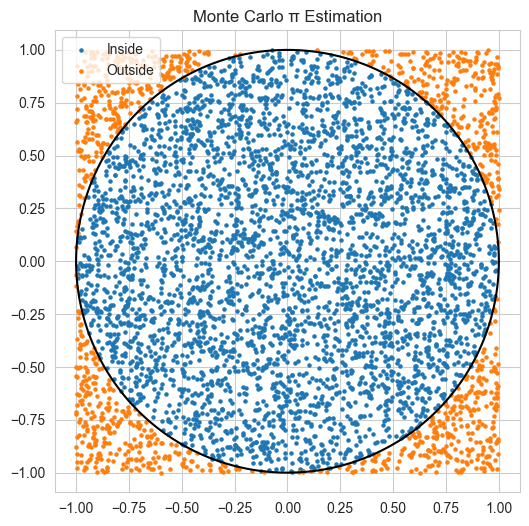

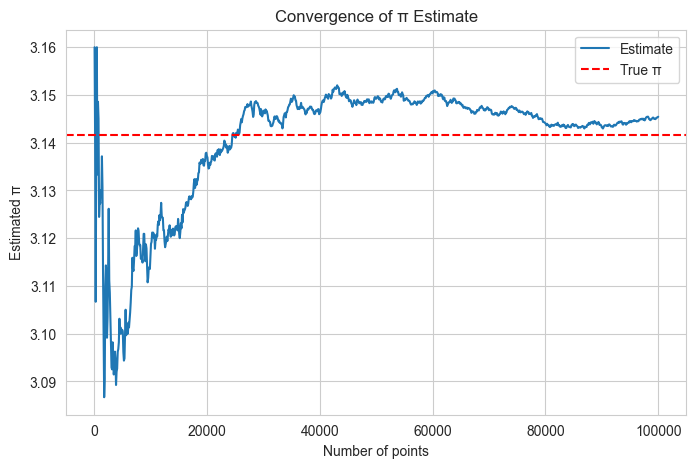

In [4]:
N = 100000

# Generate random points
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

# Check inside circle
inside = x**2 + y**2 <= 1

# Estimate pi
pi_estimate = 4 * np.sum(inside) / N

print(f"Estimated π: {pi_estimate}")
print(f"True π: {np.pi}")

n_plot = 5000

plt.figure(figsize=(6,6))
plt.scatter(x[:n_plot][inside[:n_plot]], y[:n_plot][inside[:n_plot]], s=5, label="Inside")
plt.scatter(x[:n_plot][~inside[:n_plot]], y[:n_plot][~inside[:n_plot]], s=5, label="Outside")

# Draw circle
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), color='black')

plt.legend()
plt.title("Monte Carlo π Estimation")
plt.axis("equal")
plt.show()

running_pi = []
counts = np.arange(1, N+1)

inside_cumsum = np.cumsum(inside)

for i in range(100, N+1, 100):
    running_pi.append(4 * inside_cumsum[i-1] / i)

plt.figure(figsize=(8,5))
plt.plot(range(100, N+1, 100), running_pi, label="Estimate")
plt.axhline(np.pi, color='red', linestyle='--', label="True π")

plt.xlabel("Number of points")
plt.ylabel("Estimated π")
plt.title("Convergence of π Estimate")
plt.legend()
plt.show()

The estimate converges toward π as sample size increases.

Early estimates fluctuate heavily due to randomness.

Around ~20,000–40,000 samples, the estimate stabilizes within ±0.01.

This demonstrates the Law of Large Numbers.

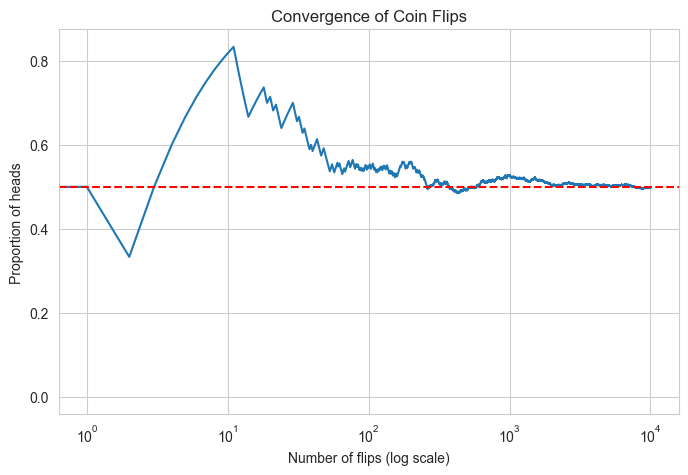

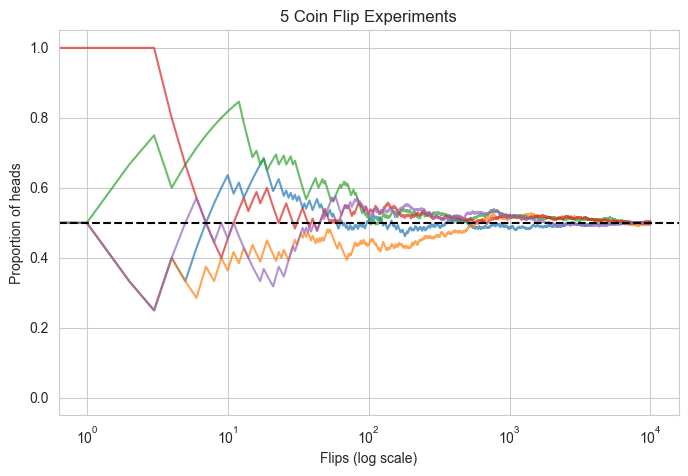

In [6]:
flips = np.random.binomial(1, 0.5, size=10000)

running_heads = np.cumsum(flips)
running_prop = running_heads / np.arange(1, 10001)

plt.figure(figsize=(8,5))
plt.plot(running_prop)
plt.axhline(0.5, color='red', linestyle='--')

plt.xscale('log')
plt.xlabel("Number of flips (log scale)")
plt.ylabel("Proportion of heads")
plt.title("Convergence of Coin Flips")
plt.show()

plt.figure(figsize=(8,5))

for i in range(5):
    flips = np.random.binomial(1, 0.5, size=10000)
    running_prop = np.cumsum(flips) / np.arange(1, 10001)
    plt.plot(running_prop, alpha=0.7)

plt.axhline(0.5, color='black', linestyle='--')

plt.xscale('log')
plt.title("5 Coin Flip Experiments")
plt.xlabel("Flips (log scale)")
plt.ylabel("Proportion of heads")
plt.show()

Early flips show high volatility.

After ~1,000–3,000 flips, results stabilize near 0.5.

All runs converge but follow slightly different paths.

Again demonstrates Law of Large Numbers.

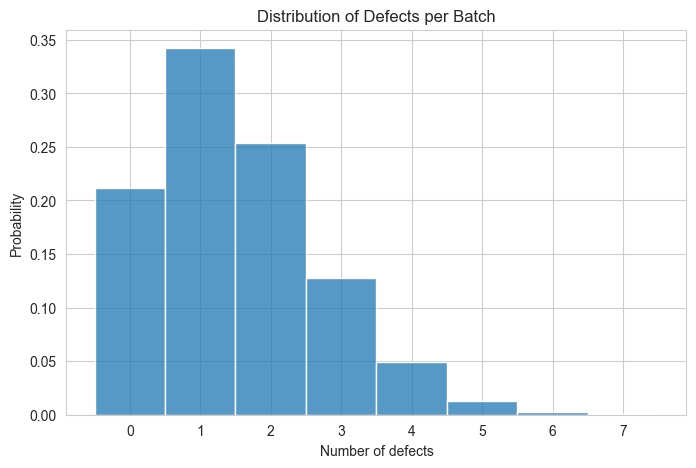

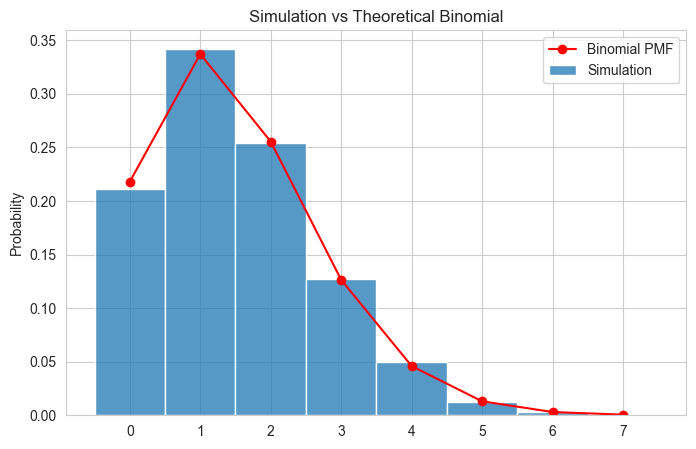

P(0 defects): 0.2114 | Theory: 0.21806537534740766
P(3+ defects): 0.1922 | Theory: 0.18920192463027874
Expected defects: 1.5109 | Theory: 1.5


In [10]:
n_batches = 10000
n = 50
p = 0.03

# Simulate batches
defects = np.random.binomial(n, p, size=n_batches)

plt.figure(figsize=(8,5))
sns.histplot(defects, bins=range(0, max(defects)+2), stat="probability", discrete=True)

plt.title("Distribution of Defects per Batch")
plt.xlabel("Number of defects")
plt.ylabel("Probability")
plt.show()

from scipy.stats import binom

k_vals = np.arange(0, max(defects)+1)
pmf = binom.pmf(k_vals, n, p)

plt.figure(figsize=(8,5))
sns.histplot(defects, bins=range(0, max(defects)+2), stat="probability", discrete=True, label="Simulation")

plt.plot(k_vals, pmf, 'o-', color='red', label="Binomial PMF")

plt.legend()
plt.title("Simulation vs Theoretical Binomial")
plt.show()

# Empirical
p_0 = np.mean(defects == 0)
p_3_plus = np.mean(defects >= 3)
expected_sim = np.mean(defects)

# Theoretical
p_0_theory = binom.pmf(0, n, p)
p_3_plus_theory = 1 - binom.cdf(2, n, p)
expected_theory = n * p

print("P(0 defects):", p_0, "| Theory:", p_0_theory)
print("P(3+ defects):", p_3_plus, "| Theory:", p_3_plus_theory)
print("Expected defects:", expected_sim, "| Theory:", expected_theory)

Simulation closely matches theoretical binomial values.

Differences are small due to random variation.

10,000 samples give very accurate estimates.

1,000 samples would be noisier but still reasonable.